# Mass-univariate screen of individual environmental items

This notebook screens individual baseline environmental items against the **NODDI + macrostructure** white-matter features in split-half A.

In [23]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

pd.set_option("display.max_rows",100)
pd.set_option("display.max_columns",100)

ROOT_DIR=Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
INPUT_DIR=ROOT_DIR/"input_data"
RESULTS_DIR=ROOT_DIR/"output_data"/"results"
OUT_DIR=RESULTS_DIR/"reviewer_revision"/"individual_environment_items"
HEATMAP_DIR=OUT_DIR/"top_item_heatmaps"
OUT_DIR.mkdir(parents=True,exist_ok=True)
HEATMAP_DIR.mkdir(parents=True,exist_ok=True)

# Easy to change later if a full-sample harmonized file becomes available.
IMAGING_FILE=RESULTS_DIR/"dfA_macro_plus_NODDI_12_10.csv"
MATCHED_GROUP_FILTER=1   # split-half A; set to None for a future full-sample file
ITEM_FILE=INPUT_DIR/"ABCD_to_send.csv"
QC_MAPPING_FILE=INPUT_DIR/"environmental_item_construct_ecological_qc_v3_final.csv"
BASELINE_EVENT="baseline_year_1_arm_1"

NUISANCE_COLS=["age","sex","t1post_dwi_contrast"]
GENERAL_EXPOSOME="General_SES"
MISSING_CODE=99999
MIN_N=100
SUMMARY_TOP_N=30
TOP_N_HEATMAPS=20
TOP_HEATMAP_RANK_BY="n_fdr_sig"  # change to "mean_abs_partial_r" if preferred

print("Imaging file:",IMAGING_FILE)
print("Item file:",ITEM_FILE)
print("QC mapping file:",QC_MAPPING_FILE)
print("Output:",OUT_DIR)


Imaging file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfA_macro_plus_NODDI_12_10.csv
Item file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/input_data/ABCD_to_send.csv
QC mapping file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/input_data/environmental_item_construct_ecological_qc_v3_final.csv
Output: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/individual_environment_items


## 1. Load split-half A imaging data and baseline environmental items

In [2]:
# Load only columns needed for this analysis to limit memory use.
keep_imaging=lambda c: (
    c.startswith("bundle_") or
    c in {"subject_id_clean","matched_group",GENERAL_EXPOSOME,*NUISANCE_COLS}
)

imaging=pd.read_csv(IMAGING_FILE,usecols=keep_imaging)
if MATCHED_GROUP_FILTER is not None:
    imaging=imaging.loc[imaging["matched_group"]==MATCHED_GROUP_FILTER].copy()

# Keep the median NODDI tract summaries and drop the duplicate mean versions.
# Macrostructural columns do not use these suffixes and are left unchanged.
mean_cols=[c for c in imaging.columns if c.startswith("bundle_") and c.endswith("_mean")]
median_cols=[c for c in imaging.columns if c.startswith("bundle_") and c.endswith("_median")]

if mean_cols:
    imaging.drop(columns=mean_cols,inplace=True)

rename_cols={c:c[:-len("_median")] for c in median_cols}
existing_after_drop=set(imaging.columns)-set(rename_cols)
collisions=set(rename_cols.values()) & existing_after_drop
if collisions:
    raise ValueError(f"Renaming *_median columns would overwrite existing columns: {sorted(collisions)[:10]}")
if rename_cols:
    imaging.rename(columns=rename_cols,inplace=True)

wm_cols=[c for c in imaging.columns if c.startswith("bundle_")]
print("Dropped *_mean WM columns:",len(mean_cols))
print("Kept/renamed *_median WM columns:",len(median_cols))
print("Imaging shape:",imaging.shape)
print("WM features:",len(wm_cols))
print("Participants:",imaging["subject_id_clean"].nunique())
assert len(wm_cols)==1302,f"Expected 1302 NODDI+macro WM features after median cleanup, found {len(wm_cols)}"

exp_items=pd.read_csv(ITEM_FILE)
exp_items=exp_items.loc[exp_items["eventname"]==BASELINE_EVENT].copy()
exp_items["subject_id_clean"]=exp_items["src_subject_id"].astype(str).str.replace(r"^NDAR_INV","",regex=True)

# Stop rather than silently deduplicate.
dups=exp_items["subject_id_clean"].duplicated(keep=False)
if dups.any():
    display(exp_items.loc[dups,["src_subject_id","subject_id_clean","eventname"]].sort_values("subject_id_clean").head(30))
    raise ValueError(f"Found {dups.sum()} baseline rows belonging to duplicated subject IDs. Resolve before continuing.")

print("Baseline item rows:",len(exp_items))
print("Unique baseline subjects:",exp_items["subject_id_clean"].nunique())

Dropped *_mean WM columns: 186
Kept/renamed *_median WM columns: 186
Imaging shape: (4078, 1308)
WM features: 1302
Participants: 4078
Baseline item rows: 11872
Unique baseline subjects: 11872


## 2. Define candidate environmental variables once

In [3]:
# Metadata / identifiers / analysis bookkeeping that should not be treated as exposures.
EXCLUDE_COLS={
    "pid","src_subject_id","subject_id_clean","uid","eventname","interview_age","Male",
    "rel_family_id","site_id_l_br","tp","val","matched_group"
}

# Start with all remaining columns. Edit EXCLUDE_COLS or ITEM_VARS here if you want to narrow later.
ITEM_VARS=[c for c in exp_items.columns if c not in EXCLUDE_COLS]

print("Candidate item variables:",len(ITEM_VARS))
print(ITEM_VARS[:30])

# ABCD_to_send.csv uses 99999 as a missing-value sentinel for environmental variables.
# Convert only those environmental item columns to real NaN values. This does NOT
# globally drop subjects; each item-specific model later uses complete cases for that item.
missing_code_counts={}
for var in ITEM_VARS:
    x=pd.to_numeric(exp_items[var],errors="coerce")
    is_missing_code=x.eq(MISSING_CODE)
    missing_code_counts[var]=int(is_missing_code.sum())
    if is_missing_code.any():
        exp_items.loc[is_missing_code,var]=np.nan

missing_code_qc=(pd.DataFrame({
    "variable":ITEM_VARS,
    "n_99999_replaced":[missing_code_counts[v] for v in ITEM_VARS]
}).sort_values("n_99999_replaced",ascending=False).reset_index(drop=True))
missing_code_qc.to_csv(OUT_DIR/"item_99999_replacements.csv",index=False)

print(f"Total {MISSING_CODE} values replaced with NaN:",missing_code_qc["n_99999_replaced"].sum())
print("Variables containing at least one 99999:",(missing_code_qc["n_99999_replaced"]>0).sum())
display(missing_code_qc.loc[missing_code_qc["n_99999_replaced"]>0].head(30))

Candidate item variables: 291
['parent_ses', 'separated_or_divorced', 'parents_married', 'living_with_partenr_or_married', 'prnts_edu', 'hshld_inc', 'demo_fam_poverty', 'school_2_y', 'school_3_y', 'school_4_y', 'school_5_y', 'school_6_y', 'school_7_y', 'school_8_y', 'school_9_y', 'school_10_y', 'school_12_y', 'school_15_y', 'school_17_y', 'fes_youth_q1', 'fes_youth_q2', 'fes_youth_q3', 'fes_youth_q4', 'fes_youth_q5', 'fes_youth_q6', 'fes_youth_q7', 'fes_youth_q8', 'fes_youth_q9', 'fam_enviro1_p', 'fam_enviro2r_p']
Total 99999 values replaced with NaN: 137787
Variables containing at least one 99999: 291


,variable,n_99999_replaced
0,reshist_addr1_scanweektemp_t0,3839
1,reshist_addr1_scanweekvpd_t6,3296
2,reshist_addr1_scanweekvpd_t5,3296
3,reshist_addr1_scanweekvpd_t1,3296
4,reshist_addr1_scanweekvpd_t2,3296
5,reshist_addr1_scanweekvpd_t3,3296
6,reshist_addr1_scanweekvpd_t0,3296
7,reshist_addr1_scanweekvpd_t4,3296
8,addr_dry_heat,3296
9,reshist_addr1_svi_grp_20142018,1142


## 2b. Final construct and ecological-level mapping

The finalized QC table is the **only source of category labels used for downstream summaries and plots**. 

In [4]:
if not QC_MAPPING_FILE.exists():
    raise FileNotFoundError(f"Final QC mapping file not found: {QC_MAPPING_FILE}")

qc_map=pd.read_csv(QC_MAPPING_FILE)
required_qc_cols=["variable","construct_category","ecological_level"]
missing_qc_cols=[c for c in required_qc_cols if c not in qc_map.columns]
if missing_qc_cols:
    raise ValueError(f"QC mapping is missing required columns: {missing_qc_cols}")
if qc_map["variable"].duplicated().any():
    dupes=qc_map.loc[qc_map["variable"].duplicated(keep=False),"variable"].tolist()
    raise ValueError(f"Duplicate variables in QC mapping: {dupes[:20]}")

qc_map=qc_map.copy()
qc_map["construct_category"]=qc_map["construct_category"].astype("string").str.strip()
qc_map["ecological_level"]=qc_map["ecological_level"].astype("string").str.strip()
qc_final=qc_map.loc[qc_map["construct_category"].ne("Needs clarification")].copy()
needs_clarification=qc_map.loc[qc_map["construct_category"].eq("Needs clarification")].copy()

print("QC variables total:",len(qc_map))
print("Excluded as Needs clarification:",len(needs_clarification))
print("QC variables retained:",len(qc_final))
if len(needs_clarification):
    display(needs_clarification[["variable","construct_category","ecological_level","description"]])

CONSTRUCT_ORDER=[
    "Socioeconomic & opportunity context","Family environment","Parenting","Culture & values",
    "School environment","Neighborhood & built environment","Physical environment",
    "Policy & structural context","Activities & enrichment","Screen & digital environment",
    "Substance-use environment","Health / developmental history"
]
ECOLOGICAL_ORDER=["Individual","Family/household","School","Peer/social","Neighborhood/community","State/policy"]

unexpected_construct=sorted(set(qc_final["construct_category"].dropna())-set(CONSTRUCT_ORDER))
unexpected_eco=sorted(set(qc_final["ecological_level"].dropna())-set(ECOLOGICAL_ORDER))
print("Unexpected construct categories:",unexpected_construct if unexpected_construct else "None")
print("Unexpected ecological levels:",unexpected_eco if unexpected_eco else "None")
assert not unexpected_construct,"QC mapping contains construct categories not in CONSTRUCT_ORDER."
assert not unexpected_eco,"QC mapping contains ecological levels not in ECOLOGICAL_ORDER."

# Explicit high-contrast colors: one hue per category, no paired light/dark shades.
CONSTRUCT_COLORS=[
    "#1f77b4","#d62728","#ff7f0e","#9467bd","#2ca02c","#8c564b",
    "#17becf","#e377c2","#bcbd22","#7f3c8d","#1b9e77","#4d4d4d"
]
construct_order=[c for c in CONSTRUCT_ORDER if c in set(qc_final["construct_category"].dropna())]
construct_palette=dict(zip(construct_order,[CONSTRUCT_COLORS[CONSTRUCT_ORDER.index(c)] for c in construct_order]))
ecological_colors=["#1b9e77","#d95f02","#7570b3","#e7298a","#66a61e","#e6ab02"]
ecological_order=[c for c in ECOLOGICAL_ORDER if c in set(qc_final["ecological_level"].dropna())]
ecological_palette=dict(zip(ecological_order,[ecological_colors[ECOLOGICAL_ORDER.index(c)] for c in ecological_order]))
construct_handles=[Patch(facecolor=construct_palette[c],label=c) for c in construct_order]

print("\nConstruct-category counts:")
display(qc_final["construct_category"].value_counts().reindex(construct_order).rename("n").to_frame())
print("\nEcological-level counts:")
display(qc_final["ecological_level"].value_counts().reindex(ecological_order).rename("n").to_frame())
print("\nConstruct x ecological level:")
display(pd.crosstab(qc_final["construct_category"],qc_final["ecological_level"]).reindex(index=construct_order,columns=ecological_order,fill_value=0))


QC variables total: 291
Excluded as Needs clarification: 0
QC variables retained: 291
Unexpected construct categories: None
Unexpected ecological levels: None

Construct-category counts:


,n
construct_category,
Socioeconomic & opportunity context,59
Family environment,25
Parenting,10
Culture & values,36
School environment,16
Neighborhood & built environment,14
Physical environment,30
Policy & structural context,5
Activities & enrichment,35



Ecological-level counts:


,n
ecological_level,
Individual,85
Family/household,73
School,16
Peer/social,7
Neighborhood/community,105
State/policy,5



Construct x ecological level:


ecological_level,Individual,Family/household,School,Peer/social,Neighborhood/community,State/policy
construct_category,,,,,,
Socioeconomic & opportunity context,0,4,0,0,55,0
Family environment,0,25,0,0,0,0
Parenting,0,10,0,0,0,0
Culture & values,2,34,0,0,0,0
School environment,0,0,16,0,0,0
Neighborhood & built environment,0,0,0,0,14,0
Physical environment,0,0,0,0,30,0
Policy & structural context,0,0,0,0,0,5
Activities & enrichment,35,0,0,0,0,0


## 3. Missingness and simple numeric-type summary

Here, `continuous_like` only means that the observed numeric column contains at least one non-integer value. `integer_or_binary` means all observed numeric values are integer-valued. This is a descriptive coding check, not a semantic claim about whether a questionnaire scale is truly continuous or ordinal.

In [5]:
def classify_numeric_column(s):
    x=pd.to_numeric(s,errors="coerce")
    n_numeric=x.notna().sum()
    if n_numeric==0:
        return "non_numeric"
    vals=x.dropna().to_numpy(dtype=float)
    if len(vals)==0:
        return "non_numeric"
    if np.all(np.isclose(vals,np.round(vals))):
        return "integer_or_binary"
    return "continuous_like"

rows=[]
for var in ITEM_VARS:
    s=exp_items[var]
    numeric=pd.to_numeric(s,errors="coerce")
    rows.append({
        "variable":var,
        "type_simple":classify_numeric_column(s),
        "n_99999_replaced":missing_code_counts[var],
        "n_nonmissing":int(numeric.notna().sum()),
        "missing_pct":100*numeric.isna().mean(),
        "n_unique_numeric":int(numeric.nunique(dropna=True))
    })

item_qc=pd.DataFrame(rows)
item_qc.to_csv(OUT_DIR/"item_missingness_and_type_after_99999_cleanup.csv",index=False)

type_counts=item_qc["type_simple"].value_counts(dropna=False)
print("Variable-type summary after missing-code cleanup:")
for label,n in type_counts.items():
    print(f"  {label}: {n}/{len(item_qc)} ({100*n/len(item_qc):.1f}%)")

print("\nMissingness by variable after converting 99999 -> NaN:")
display(item_qc.sort_values("missing_pct",ascending=False).reset_index(drop=True))

Variable-type summary after missing-code cleanup:
  continuous_like: 177/291 (60.8%)
  integer_or_binary: 114/291 (39.2%)

Missingness by variable after converting 99999 -> NaN:


,variable,type_simple,n_99999_replaced,n_nonmissing,missing_pct,n_unique_numeric
0,reshist_addr1_scanweektemp_t0,continuous_like,3839,8033,32.336590,3649
1,reshist_addr1_scanweekvpd_t6,continuous_like,3296,8576,27.762803,7515
2,reshist_addr1_scanweekvpd_t5,continuous_like,3296,8576,27.762803,7524
3,reshist_addr1_scanweekvpd_t1,continuous_like,3296,8576,27.762803,7526
4,reshist_addr1_scanweekvpd_t2,continuous_like,3296,8576,27.762803,7520
...,...,...,...,...,...,...
286,fes_youth_q4,integer_or_binary,25,11847,0.210580,2
287,fes_youth_q3,integer_or_binary,25,11847,0.210580,2
288,fes_youth_q2,integer_or_binary,25,11847,0.210580,2
289,parent_ses,continuous_like,25,11847,0.210580,1287


## 4. Merge environmental items into imaging data

In [6]:
merge_cols=["subject_id_clean"]+ITEM_VARS
analysis_df=imaging.merge(exp_items[merge_cols],on="subject_id_clean",how="left",validate="one_to_one")

print("Merged shape:",analysis_df.shape)
print("Participants with any item data:",analysis_df[ITEM_VARS].notna().any(axis=1).sum())

# Coerce nuisance variables and candidate items to numeric.
# Common string sex labels are mapped if needed.
if analysis_df["sex"].dtype==object:
    sex_map={"M":1,"Male":1,"male":1,"F":0,"Female":0,"female":0}
    analysis_df["sex"]=analysis_df["sex"].replace(sex_map)

for c in NUISANCE_COLS+[GENERAL_EXPOSOME]+ITEM_VARS:
    if c in analysis_df.columns:
        analysis_df[c]=pd.to_numeric(analysis_df[c],errors="coerce")

# WM completeness is handled once here. Environmental missingness is NOT dropped globally:
# run_mass_partial_r() uses complete cases separately for each target item.
wm_complete=analysis_df[wm_cols].notna().all(axis=1)
print(f"Participants complete across all {len(wm_cols)} WM features: {wm_complete.sum()}/{len(analysis_df)}")
if wm_complete.mean()<0.99:
    warnings.warn("More than 1% of participants have missing WM values. This notebook uses complete WM rows for the vectorized analysis.")

analysis_df=analysis_df.loc[wm_complete].reset_index(drop=True)

# Save missingness in the actual imaging sample after merge.
imaging_sample_missingness=pd.DataFrame({
    "variable":ITEM_VARS,
    "n_nonmissing_in_imaging_sample":[analysis_df[v].notna().sum() for v in ITEM_VARS],
    "missing_pct_in_imaging_sample":[100*analysis_df[v].isna().mean() for v in ITEM_VARS]
}).sort_values("missing_pct_in_imaging_sample",ascending=False)
imaging_sample_missingness.to_csv(OUT_DIR/"item_missingness_in_imaging_sample.csv",index=False)
display(imaging_sample_missingness.head(30))

gc.collect()

Merged shape: (4078, 1599)
Participants with any item data: 4078
Participants complete across all 1302 WM features: 4078/4078


,variable,n_nonmissing_in_imaging_sample,missing_pct_in_imaging_sample
266,reshist_addr1_scanweektemp_t0,2769,32.099068
267,reshist_addr1_scanweekvpd_t6,3002,26.385483
268,reshist_addr1_scanweekvpd_t5,3002,26.385483
272,reshist_addr1_scanweekvpd_t1,3002,26.385483
271,reshist_addr1_scanweekvpd_t2,3002,26.385483
270,reshist_addr1_scanweekvpd_t3,3002,26.385483
273,reshist_addr1_scanweekvpd_t0,3002,26.385483
269,reshist_addr1_scanweekvpd_t4,3002,26.385483
286,addr_dry_heat,3002,26.385483
275,reshist_addr1_svi_grp_20142018,3747,8.116724


0

## 4b. Sanity checks after missing-value cleanup

These checks are descriptive only. They help verify that known socioeconomic/family variables have sensible distributions and that the `99999` sentinel is no longer present before running the full screen.

In [7]:
sanity_vars=[
    "hshld_inc","prnts_edu","demo_fam_poverty","addr_poverty","parents_married",
    "parent_ses","nbrhd_safety_parent","sai_p_lmusic","sai_p_read"
]
sanity_vars=[v for v in sanity_vars if v in analysis_df.columns]

print("Any 99999 values remaining in candidate environmental items?")
remaining_99999={v:int((analysis_df[v]==MISSING_CODE).sum()) for v in ITEM_VARS if (analysis_df[v]==MISSING_CODE).any()}
print(remaining_99999 if remaining_99999 else "No")

print("\nSelected variable distributions:")
display(analysis_df[sanity_vars].describe().T)

if GENERAL_EXPOSOME in analysis_df.columns and sanity_vars:
    print("\nCorrelations with General Exposome (descriptive sanity check):")
    corr_vars=[GENERAL_EXPOSOME]+sanity_vars
    display(analysis_df[corr_vars].corr()[GENERAL_EXPOSOME].sort_values(ascending=False).to_frame("r_with_General_SES"))

Any 99999 values remaining in candidate environmental items?
No

Selected variable distributions:


,count,mean,std,min,25%,50%,75%,max
hshld_inc,4074.0,7.307399,2.302208,1.000000,6.000000,8.000000,9.000000,10.000000
prnts_edu,4074.0,16.542271,2.586929,3.000000,15.000000,17.000000,18.500000,21.000000
demo_fam_poverty,4074.0,0.439654,1.066659,0.000000,0.000000,0.000000,0.000000,7.000000
addr_poverty,3747.0,-0.074728,0.956405,-1.706709,-0.809779,-0.294856,0.492216,3.148430
parents_married,4074.0,0.700785,0.457970,0.000000,0.000000,1.000000,1.000000,1.000000
parent_ses,4074.0,0.016521,0.975290,-3.948624,-0.586207,0.274182,0.742257,1.577392
nbrhd_safety_parent,4074.0,0.041050,0.997900,-3.020497,-0.577305,0.120750,0.818805,1.167833
sai_p_lmusic,4074.0,0.838243,0.368273,0.000000,1.000000,1.000000,1.000000,1.000000
sai_p_read,4074.0,0.746932,0.434823,0.000000,0.000000,1.000000,1.000000,1.000000



Correlations with General Exposome (descriptive sanity check):


,r_with_General_SES
General_SES,1.000000
parent_ses,0.876607
hshld_inc,0.849745
prnts_edu,0.735225
parents_married,0.507049
nbrhd_safety_parent,0.423387
sai_p_read,0.272439
sai_p_lmusic,0.146170
demo_fam_poverty,-0.404055
addr_poverty,-0.746060


## 5. Vectorized mass-univariate partial-r function

For each environmental item, the function uses participants complete for that item and the nuisance covariates. It residualizes the item and all WM features with respect to age, sex, and image quality, then computes the partial correlation. FDR correction is performed **separately for each item across its 1,302 WM tests**.

In [8]:
def run_mass_partial_r(df,target,wm_cols,nuisance_cols,min_n=100):
    cols=[target]+nuisance_cols+wm_cols

    # Item-specific complete cases: a participant is excluded only from this target's
    # model if the target or nuisance covariates are missing. WM completeness was
    # already enforced once above.
    d=df[cols].dropna(subset=[target]+nuisance_cols).copy()
    n=len(d)

    if n<min_n:
        return None,f"n<{min_n}"
    if d[target].nunique(dropna=True)<2:
        return None,"<2 unique values"

    x=d[target].to_numpy(dtype=float)
    Y=d[wm_cols].to_numpy(dtype=float)
    C=d[nuisance_cols].to_numpy(dtype=float)
    C=np.column_stack([np.ones(n),C])

    # nuisance residualization
    bx=np.linalg.lstsq(C,x,rcond=None)[0]
    bY=np.linalg.lstsq(C,Y,rcond=None)[0]
    rx=x-C@bx
    rY=Y-C@bY

    rx=rx-rx.mean()
    rY=rY-rY.mean(axis=0,keepdims=True)
    denom=np.sqrt(np.sum(rx**2)*np.sum(rY**2,axis=0))
    r=np.divide(rx@rY,denom,out=np.full(Y.shape[1],np.nan),where=denom>0)
    r=np.clip(r,-0.999999999,0.999999999)

    rank_c=np.linalg.matrix_rank(C)
    dfree=n-rank_c-1
    t=r*np.sqrt(dfree/(1-r**2))
    p=2*stats.t.sf(np.abs(t),df=dfree)

    # BH-FDR separately within this item's 1,302 WM tests.
    p_fdr=np.full_like(p,np.nan,dtype=float)
    valid=np.isfinite(p)
    if valid.any():
        p_fdr[valid]=multipletests(p[valid],alpha=.05,method="fdr_bh")[1]

    out=pd.DataFrame({
        "variable":target,
        "feature":wm_cols,
        "partial_r":r,
        "t_stat":t,
        "p_value":p,
        "p_fdr":p_fdr,
        "n":n
    })
    return out,None

## 6. General Exposome reference map

In [9]:
general_results,err=run_mass_partial_r(
    analysis_df,GENERAL_EXPOSOME,wm_cols,NUISANCE_COLS,min_n=MIN_N
)
if err:
    raise RuntimeError(f"Could not fit General Exposome reference: {err}")

general_results.to_csv(OUT_DIR/"General_SES_mass_univariate_reference.csv",index=False)
general_sig=set(general_results.loc[general_results["p_fdr"]<.05,"feature"])
print("General Exposome N:",general_results["n"].iloc[0])
print("General Exposome FDR-significant features:",len(general_sig))

General Exposome N: 4078
General Exposome FDR-significant features: 1119


## 7. Run all environmental items

In [10]:
all_results=[]
summary_rows=[]
skipped=[]

general_map=general_results.set_index("feature")["partial_r"]

for i,var in enumerate(ITEM_VARS,1):
    print(f"[{i}/{len(ITEM_VARS)}] {var}")
    res,err=run_mass_partial_r(analysis_df,var,wm_cols,NUISANCE_COLS,min_n=MIN_N)
    if err:
        skipped.append({"variable":var,"reason":err})
        continue

    item_map=res.set_index("feature")["partial_r"]
    common=item_map.index.intersection(general_map.index)
    map_r=np.corrcoef(item_map.loc[common],general_map.loc[common])[0,1]

    item_sig=set(res.loc[res["p_fdr"]<.05,"feature"])
    overlap=item_sig & general_sig

    summary_rows.append({
        "variable":var,
        "n":int(res["n"].iloc[0]),
        "n_unique":int(analysis_df[var].nunique(dropna=True)),
        "missing_pct_in_imaging_sample":100*analysis_df[var].isna().mean(),
        "mean_abs_partial_r":res["partial_r"].abs().mean(),
        "median_abs_partial_r":res["partial_r"].abs().median(),
        "max_abs_partial_r":res["partial_r"].abs().max(),
        "n_fdr_sig":len(item_sig),
        "map_r_vs_general_exposome":map_r,
        "fdr_overlap_with_general_n":len(overlap),
        "fdr_overlap_pct_of_item":100*len(overlap)/len(item_sig) if item_sig else np.nan
    })
    all_results.append(res)

results_long=pd.concat(all_results,ignore_index=True) if all_results else pd.DataFrame()
summary=pd.DataFrame(summary_rows)
skipped=pd.DataFrame(skipped)

# Attach finalized QC labels after modeling; the regressions above are unchanged.
summary=summary.merge(qc_map[["variable","construct_category","ecological_level"]],on="variable",how="left",validate="one_to_one")
if summary[["construct_category","ecological_level"]].isna().any(axis=1).any():
    unmapped=summary.loc[summary[["construct_category","ecological_level"]].isna().any(axis=1),"variable"].tolist()
    raise ValueError(f"Modeled variables missing finalized QC labels: {unmapped[:20]}")
summary["abs_map_r_vs_general_exposome"]=summary["map_r_vs_general_exposome"].abs()
summary["rank_mean_abs_r"]=summary["mean_abs_partial_r"].rank(method="min",ascending=False).astype(int)
summary["rank_n_fdr"]=summary["n_fdr_sig"].rank(method="min",ascending=False).astype(int)
summary=summary.sort_values("rank_mean_abs_r").reset_index(drop=True)

# Exclude unresolved labels only from downstream summaries/plots, not from the regression loop.
summary_plot=summary.loc[summary["construct_category"].ne("Needs clarification")].copy()
results_plot=results_long.loc[results_long["variable"].isin(summary_plot["variable"])].copy()
summary_plot["rank_mean_abs_r_filtered"]=summary_plot["mean_abs_partial_r"].rank(method="min",ascending=False).astype(int)
summary_plot["rank_n_fdr_filtered"]=summary_plot["n_fdr_sig"].rank(method="min",ascending=False).astype(int)

results_long.to_csv(OUT_DIR/"all_item_mass_univariate_results.csv",index=False)
summary.to_csv(OUT_DIR/"item_mass_univariate_summary.csv",index=False)
summary_plot.to_csv(OUT_DIR/"item_mass_univariate_summary_qc_filtered.csv",index=False)
skipped.to_csv(OUT_DIR/"skipped_items.csv",index=False)

print("\nModeled items before QC filtering:",len(summary))
print("Modeled items retained after QC filtering:",len(summary_plot))
print("Modeled Needs clarification items excluded downstream:",len(summary)-len(summary_plot))
print("Skipped items:",len(skipped))
print("\nConstruct-category counts among retained modeled items:")
display(summary_plot["construct_category"].value_counts().rename_axis("construct_category").reset_index(name="n"))
print("\nEcological-level counts among retained modeled items:")
display(summary_plot["ecological_level"].value_counts().rename_axis("ecological_level").reset_index(name="n"))
print("\nConstruct category x ecological level:")
display(pd.crosstab(summary_plot["construct_category"],summary_plot["ecological_level"]).reindex(index=construct_order,columns=ecological_order,fill_value=0))

display(summary_plot.head(30))
if len(skipped):
    display(skipped)


[1/291] parent_ses
[2/291] separated_or_divorced
[3/291] parents_married
[4/291] living_with_partenr_or_married
[5/291] prnts_edu
[6/291] hshld_inc
[7/291] demo_fam_poverty
[8/291] school_2_y
[9/291] school_3_y
[10/291] school_4_y
[11/291] school_5_y
[12/291] school_6_y
[13/291] school_7_y
[14/291] school_8_y
[15/291] school_9_y
[16/291] school_10_y
[17/291] school_12_y
[18/291] school_15_y
[19/291] school_17_y
[20/291] fes_youth_q1
[21/291] fes_youth_q2
[22/291] fes_youth_q3
[23/291] fes_youth_q4
[24/291] fes_youth_q5
[25/291] fes_youth_q6
[26/291] fes_youth_q7
[27/291] fes_youth_q8
[28/291] fes_youth_q9
[29/291] fam_enviro1_p
[30/291] fam_enviro2r_p
[31/291] fam_enviro3_p
[32/291] fam_enviro4r_p
[33/291] fam_enviro5_p
[34/291] fam_enviro6_p
[35/291] fam_enviro7r_p
[36/291] fam_enviro8_p
[37/291] fam_enviro9r_p
[38/291] parent_monitor_q1_y
[39/291] parent_monitor_q2_y
[40/291] parent_monitor_q3_y
[41/291] parent_monitor_q4_y
[42/291] parent_monitor_q5_y
[43/291] neighborhood_crime_y
[

,construct_category,n
0,Socioeconomic & opportunity context,59
1,Culture & values,36
2,Activities & enrichment,35
3,Physical environment,30
4,Family environment,25
5,School environment,16
6,Screen & digital environment,15
7,Neighborhood & built environment,14
8,Substance-use environment,13
9,Parenting,10



Ecological-level counts among retained modeled items:


,ecological_level,n
0,Neighborhood/community,105
1,Family/household,73
2,Individual,60
3,School,16
4,Peer/social,7
5,State/policy,5



Construct category x ecological level:


ecological_level,Individual,Family/household,School,Peer/social,Neighborhood/community,State/policy
construct_category,,,,,,
Socioeconomic & opportunity context,0,4,0,0,55,0
Family environment,0,25,0,0,0,0
Parenting,0,10,0,0,0,0
Culture & values,2,34,0,0,0,0
School environment,0,0,16,0,0,0
Neighborhood & built environment,0,0,0,0,14,0
Physical environment,0,0,0,0,30,0
Policy & structural context,0,0,0,0,0,5
Activities & enrichment,35,0,0,0,0,0


,variable,n,n_unique,missing_pct_in_imaging_sample,mean_abs_partial_r,median_abs_partial_r,max_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,construct_category,ecological_level,abs_map_r_vs_general_exposome,rank_mean_abs_r,rank_n_fdr,rank_mean_abs_r_filtered,rank_n_fdr_filtered
0,parent_ses,4074,564,0.098087,0.076370,0.072040,0.254469,1046,0.989394,1032,98.661568,Socioeconomic & opportunity context,Family/household,0.989394,1,2,1,2
1,hshld_inc,4074,349,0.098087,0.075859,0.072770,0.247932,1057,0.991361,1043,98.675497,Socioeconomic & opportunity context,Family/household,0.991361,2,1,2,1
2,addr_poverty,3747,2798,8.116724,0.075079,0.071419,0.240523,1045,-0.984194,1025,98.086124,Socioeconomic & opportunity context,Neighborhood/community,0.984194,3,3,3,3
3,reshist_addr1_coi_c5_coi_nat,3747,5,8.116724,0.072278,0.067991,0.232815,1029,0.982516,1008,97.959184,Socioeconomic & opportunity context,Neighborhood/community,0.982516,4,4,4,4
4,reshist_addr1_coi_se_single,3747,2444,8.116724,0.067743,0.064233,0.216217,1006,-0.964849,980,97.415507,Socioeconomic & opportunity context,Neighborhood/community,0.964849,5,6,5,6
5,reshist_addr1_coi_se_public,3747,2475,8.116724,0.067624,0.064563,0.217448,1000,-0.976114,982,98.200000,Socioeconomic & opportunity context,Neighborhood/community,0.976114,6,7,6,7
6,reshist_addr1_coi_se_occ,3747,2443,8.116724,0.067208,0.062923,0.223991,969,0.983407,962,99.277606,Socioeconomic & opportunity context,Neighborhood/community,0.983407,7,10,7,10
7,reshist_addr1_coi_se_povrate,3747,2469,8.116724,0.066697,0.064688,0.213808,1011,-0.971571,996,98.516320,Socioeconomic & opportunity context,Neighborhood/community,0.971571,8,5,8,5
8,reshist_addr1_adi_perc,3747,166,8.116724,0.065411,0.059520,0.222248,954,-0.978081,935,98.008386,Socioeconomic & opportunity context,Neighborhood/community,0.978081,9,15,9,15
9,reshist_addr1_coi_r_he_nat,3747,99,8.116724,0.064951,0.060229,0.208812,984,0.982420,973,98.882114,Socioeconomic & opportunity context,Neighborhood/community,0.982420,10,8,10,8


,variable,reason
0,screentime_smq_use___7,<2 unique values
1,screentime_smq_use___8,<2 unique values
2,screentime_smq_use___9,<2 unique values
3,screentime_smq_use___10,<2 unique values
4,screentime_smq_use___11,<2 unique values
5,screentime_smq_use___1,<2 unique values
6,screentime_smq_use___2,<2 unique values
7,screentime_smq_use___3,<2 unique values
8,screentime_smq_use___4,<2 unique values
9,screentime_smq_use___5,<2 unique values


## 8. Feature parsing for heatmaps

In [11]:
PREFIXES=["Association_","Cerebellum_","Commissure_","ProjectionBrainstem_","ProjectionBasalGanglia_"]

METRIC_ORDER=[
    "NODDI_ICVF","NODDI_ISOVF","NODDI_OD",
    "1st_quarter_volume_mm3","2nd_and_3rd_quarter_volume_mm3","4th_quarter_volume_mm3",
    "volume_of_end_branches_1","volume_of_end_branches_2","total_volume_mm3",
    "area_of_end_region_1_mm2","area_of_end_region_2_mm2","total_area_of_end_regions_mm2",
    "total_surface_area_mm2","radius_of_end_region_1_mm","radius_of_end_region_2_mm",
    "total_radius_of_end_regions_mm","irregularity","curl","elongation","mean_length_mm","span_mm"
]

def parse_feature(feature):
    parts=feature.split("_")
    if len(parts)<4 or parts[0]!="bundle":
        return None,None
    bundle=parts[1]+"_"+parts[2]
    metric="_".join(parts[3:])
    return bundle,metric

def clean_bundle_label(bundle):
    x=bundle
    for p in PREFIXES:
        if x.startswith(p):
            x=x[len(p):]
            break
    side=""
    if x.endswith("L"):
        x=x[:-1]; side=" (L)"
    elif x.endswith("R"):
        x=x[:-1]; side=" (R)"
    x=re.sub(r"(?<!^)(?=[A-Z])"," ",x).replace("_"," ")
    return x+side

def clean_metric_label(metric):
    lookup={
        "NODDI_ICVF":"NODDI ICVF","NODDI_ISOVF":"NODDI ISOVF","NODDI_OD":"NODDI OD",
        "1st_quarter_volume_mm3":"1st Quarter Volume","2nd_and_3rd_quarter_volume_mm3":"2nd + 3rd Quarter Volume",
        "4th_quarter_volume_mm3":"4th Quarter Volume","volume_of_end_branches_1":"Volume of End Branches 1",
        "volume_of_end_branches_2":"Volume of End Branches 2","total_volume_mm3":"Total Volume",
        "area_of_end_region_1_mm2":"Area of End Region 1","area_of_end_region_2_mm2":"Area of End Region 2",
        "total_area_of_end_regions_mm2":"Total Area of End Regions","total_surface_area_mm2":"Total Surface Area",
        "radius_of_end_region_1_mm":"Radius of End Region 1","radius_of_end_region_2_mm":"Radius of End Region 2",
        "total_radius_of_end_regions_mm":"Total Radius of End Regions","irregularity":"Irregularity","curl":"Curl",
        "elongation":"Elongation","mean_length_mm":"Mean Length","span_mm":"Span"
    }
    return lookup.get(metric,metric)

feature_meta=pd.DataFrame({"feature":wm_cols})
feature_meta[["bundle","metric"]]=feature_meta["feature"].apply(lambda x:pd.Series(parse_feature(x)))
feature_meta["bundle_label"]=feature_meta["bundle"].map(clean_bundle_label)
feature_meta["metric_label"]=feature_meta["metric"].map(clean_metric_label)

bundle_order=feature_meta["bundle"].drop_duplicates().tolist()
metric_order=[m for m in METRIC_ORDER if m in set(feature_meta["metric"])]
print("Bundles:",len(bundle_order),"Metrics:",len(metric_order))

Bundles: 62 Metrics: 18


## 10. Brain-wide ranking by mean absolute partial r

Each environmental item occupies one x-position and is ranked globally by mean absolute partial r. Small points show the absolute partial-r values for all 1,302 WM features and the black line shows the item's mean absolute partial r. Two versions use the same ranking: one colored by finalized **construct category** and one by **ecological level**. Variables marked `Needs clarification` are excluded.


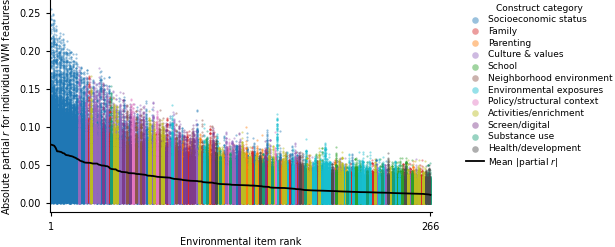

Top 25 by mean |partial r|:


,variable,construct_category,ecological_level,n,missing_pct_in_imaging_sample,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome
0,parent_ses,Socioeconomic & opportunity context,Family/household,4074,0.098087,0.076370,1046,0.989394
1,hshld_inc,Socioeconomic & opportunity context,Family/household,4074,0.098087,0.075859,1057,0.991361
2,addr_poverty,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.075079,1045,-0.984194
3,reshist_addr1_coi_c5_coi_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.072278,1029,0.982516
4,reshist_addr1_coi_se_single,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.067743,1006,-0.964849
5,reshist_addr1_coi_se_public,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.067624,1000,-0.976114
6,reshist_addr1_coi_se_occ,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.067208,969,0.983407
7,reshist_addr1_coi_se_povrate,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.066697,1011,-0.971571
8,reshist_addr1_adi_perc,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.065411,954,-0.978081
9,reshist_addr1_coi_r_he_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.064951,984,0.982420


In [55]:
from figure_formatting import setup_figure, save_figure
import logging
import matplotlib as mpl

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

mpl.rcParams["font.family"]="sans-serif"
mpl.rcParams["font.sans-serif"]=["DejaVu Sans","Arial","Liberation Sans"]

W_MM=160
H_MM=75

rank_mean=summary_plot.sort_values("mean_abs_partial_r",ascending=False)["variable"].tolist()
rank_lookup={v:i for i,v in enumerate(rank_mean)}

plot_df=results_plot[["variable","partial_r"]].merge(
    qc_final[["variable","construct_category"]],
    on="variable",how="inner",validate="many_to_one"
)
plot_df["x"]=plot_df["variable"].map(rank_lookup)
plot_df["abs_partial_r"]=plot_df["partial_r"].abs()

mean_line=summary_plot.set_index("variable").loc[rank_mean,"mean_abs_partial_r"].to_numpy()

legend_labels={
    "Socioeconomic & opportunity context":"Socioeconomic status",
    "Family environment":"Family",
    "Parenting":"Parenting",
    "Culture & values":"Culture & values",
    "School environment":"School",
    "Neighborhood & built environment":"Neighborhood environment",
    "Physical environment":"Environmental exposures",
    "Policy & structural context":"Policy/structural context",
    "Activities & enrichment":"Activities/enrichment",
    "Screen & digital environment":"Screen/digital",
    "Substance-use environment":"Substance use",
    "Health / developmental history":"Health/development"
}

fig,ax=setup_figure(
    width_mm=W_MM,
    height_mm=H_MM,
    margins_mm=(15,48,13,8),
    nrows=1,
    ncols=1,
    axes_linewidth=0.8,
    base_pt=7,
    label_pt=7,
    title_pt=7
)

for category in construct_order:
    d=plot_df.loc[plot_df["construct_category"]==category]
    if len(d):
        ax.scatter(
            d["x"],d["abs_partial_r"],
            s=2.5,alpha=.45,rasterized=True,
            color=construct_palette[category],
            linewidths=0,
            label=legend_labels.get(category,category)
        )

ax.plot(
    np.arange(len(rank_mean)),mean_line,
    lw=1.3,color="black",
    label=r"Mean |partial $r$|",
    zorder=10
)

ax.set_xlim(-1,len(rank_mean))
ax.set_xlabel("Environmental item rank")
ax.set_ylabel(r"Absolute partial $r$ for individual WM features")

ax.set_xticks([0,len(rank_mean)-1] if len(rank_mean)>1 else [0])
ax.set_xticklabels(["1",str(len(rank_mean))] if len(rank_mean)>1 else ["1"])

ax.tick_params(axis="both",width=0.8,length=3,direction="out")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Construct category",
    bbox_to_anchor=(1.08,1),
    loc="upper left",
    frameon=False,
    fontsize=6.5,
    title_fontsize=6.5,
    markerscale=3,
    handletextpad=.4,
    labelspacing=.3,
    borderaxespad=0
)

save_figure(
    fig,
    OUT_DIR/"brainwide_rank_mean_abs_partial_r.svg",
    autofit=False
)

fig.savefig(
    OUT_DIR/"brainwide_rank_mean_abs_partial_r.png",
    dpi=600
)

plt.show()

print("Top 25 by mean |partial r|:")
display(
    summary_plot
    .sort_values("mean_abs_partial_r",ascending=False)
    .head(25)[[
        "variable",
        "construct_category",
        "ecological_level",
        "n",
        "missing_pct_in_imaging_sample",
        "mean_abs_partial_r",
        "n_fdr_sig",
        "map_r_vs_general_exposome"
    ]]
)

## 11. Brain-wide ranking by number of FDR-significant WM features

Items are ranked by the number of FDR-significant WM features and bars are colored using the same stable `construct_palette` as the construct-based mean-|partial r| figure.


In [33]:
top5_mean=summary_plot.sort_values("mean_abs_partial_r",ascending=False).head(5)["variable"].tolist()
top5_fdr=rank_fdr.head(5)["variable"].tolist()

top5_overlap=set(top5_mean)&set(top5_fdr)

print("Top 5 by mean |partial r|:",top5_mean)
print("Top 5 by FDR-significant features:",top5_fdr)
print(f"Top-5 overlap: {len(top5_overlap)}/5")
print("Shared variables:",top5_overlap)

Top 5 by mean |partial r|: ['parent_ses', 'hshld_inc', 'addr_poverty', 'reshist_addr1_coi_c5_coi_nat', 'reshist_addr1_coi_se_single']
Top 5 by FDR-significant features: ['hshld_inc', 'parent_ses', 'addr_poverty', 'reshist_addr1_coi_c5_coi_nat', 'reshist_addr1_coi_se_povrate']
Top-5 overlap: 4/5
Shared variables: {'addr_poverty', 'hshld_inc', 'parent_ses', 'reshist_addr1_coi_c5_coi_nat'}


82 of 266 environmental items (30.8%) had no FDR-significant WM features.


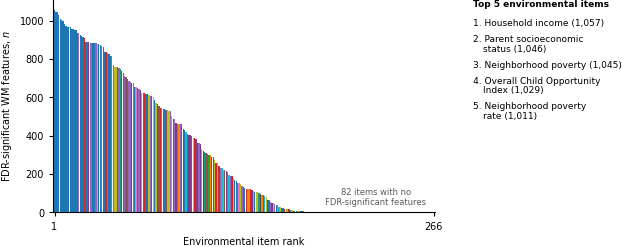

Top 25 by number of FDR-significant features:


,variable,construct_category,ecological_level,n,missing_pct_in_imaging_sample,n_fdr_sig,mean_abs_partial_r,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,map_r_vs_general_exposome
0,hshld_inc,Socioeconomic & opportunity context,Family/household,4074,0.098087,1057,0.075859,1043,98.675497,0.991361
1,parent_ses,Socioeconomic & opportunity context,Family/household,4074,0.098087,1046,0.076370,1032,98.661568,0.989394
2,addr_poverty,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,1045,0.075079,1025,98.086124,-0.984194
3,reshist_addr1_coi_c5_coi_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,1029,0.072278,1008,97.959184,0.982516
4,reshist_addr1_coi_se_povrate,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,1011,0.066697,996,98.516320,-0.971571
5,reshist_addr1_coi_se_single,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,1006,0.067743,980,97.415507,-0.964849
6,reshist_addr1_coi_se_public,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,1000,0.067624,982,98.200000,-0.976114
7,reshist_addr1_coi_r_he_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,984,0.064951,973,98.882114,0.982420
8,reshist_addr1_adi_unemp,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,971,0.060761,948,97.631308,-0.967827
9,reshist_addr1_coi_se_occ,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,969,0.067208,962,99.277606,0.983407


In [47]:
from figure_formatting import setup_figure, save_figure

rank_fdr=summary_plot.sort_values(
    ["n_fdr_sig","mean_abs_partial_r"],
    ascending=[False,False]
).reset_index(drop=True)

missing_bar_categories=sorted(set(rank_fdr["construct_category"])-set(construct_palette))
assert not missing_bar_categories,f"Missing construct colors for: {missing_bar_categories}"

bar_colors=rank_fdr["construct_category"].map(construct_palette).tolist()

n_items=len(rank_fdr)
n_zero=int((rank_fdr["n_fdr_sig"]==0).sum())
n_nonzero=n_items-n_zero
zero_pct=100*n_zero/n_items if n_items else np.nan

print(f"{n_zero} of {n_items} environmental items ({zero_pct:.1f}%) had no FDR-significant WM features.")

fig,ax=setup_figure(
    width_mm=W_MM,
    height_mm=H_MM,
    margins_mm=(15,48,13,8),
    nrows=1,
    ncols=1,
    axes_linewidth=0.8,
    base_pt=7,
    label_pt=7,
    title_pt=7
)

x=np.arange(n_items)
ax.bar(
    x,
    rank_fdr["n_fdr_sig"].to_numpy(),
    color=bar_colors,
    width=.9,
    linewidth=0
)

ax.set_xlim(-1,n_items)
ax.set_xlabel("Environmental item rank")
ax.set_ylabel(r"FDR-significant WM features, $n$")

ax.set_xticks([0,n_items-1] if n_items>1 else [0])
ax.set_xticklabels(["1",str(n_items)] if n_items>1 else ["1"])

ax.tick_params(axis="both",width=0.8,length=3,direction="out")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Zero-count items occur at the end because rank_fdr is sorted descending
if n_zero>0:
    y_max=ax.get_ylim()[1]
    ax.text(
        n_nonzero+(n_zero-1)/2,
        .025*y_max,
        f"{n_zero} items with no\nFDR-significant features",
        ha="center",
        va="bottom",
        fontsize=6,
        color="0.35"
    )

figure_labels={
    "hshld_inc":("Household income",None),
    "parent_ses":("Parent socioeconomic","status"),
    "addr_poverty":("Neighborhood poverty",None),
    "reshist_addr1_coi_c5_coi_nat":("Overall Child Opportunity","Index"),
    "reshist_addr1_coi_se_povrate":("Neighborhood poverty","rate")
}

top5=rank_fdr.head(5).copy()
x_callout=1.10

ax.text(
    x_callout,1,
    "Top 5 environmental items",
    transform=ax.transAxes,
    ha="left",va="top",
    fontsize=6.5,
    fontweight="semibold",
    clip_on=False
)

y=.91
line_gap=.075
wrap_gap=.045

for i,(_,row) in enumerate(top5.iterrows(),start=1):
    label1,label2=figure_labels.get(row["variable"],(row["variable"],None))
    count=f"{int(row['n_fdr_sig']):,}"

    if label2 is None:
        ax.text(
            x_callout,y,
            f"{i}. {label1} ({count})",
            transform=ax.transAxes,
            ha="left",va="top",
            fontsize=6.5,
            clip_on=False
        )
        y-=line_gap
    else:
        ax.text(
            x_callout,y,
            f"{i}. {label1}",
            transform=ax.transAxes,
            ha="left",va="top",
            fontsize=6.5,
            clip_on=False
        )
        ax.text(
            x_callout+.025,y-wrap_gap,
            f"{label2} ({count})",
            transform=ax.transAxes,
            ha="left",va="top",
            fontsize=6.5,
            clip_on=False
        )
        y-=line_gap+wrap_gap

save_figure(
    fig,
    OUT_DIR/"brainwide_rank_n_fdr_significant_by_construct.svg",
    autofit=False
)

fig.savefig(
    OUT_DIR/"brainwide_rank_n_fdr_significant_by_construct.png",
    dpi=600
)

plt.show()

print("Top 25 by number of FDR-significant features:")
display(
    rank_fdr.head(25)[[
        "variable",
        "construct_category",
        "ecological_level",
        "n",
        "missing_pct_in_imaging_sample",
        "n_fdr_sig",
        "mean_abs_partial_r",
        "fdr_overlap_with_general_n",
        "fdr_overlap_pct_of_item",
        "map_r_vs_general_exposome"
    ]]
)

## 12. General Exposome comparison

In [15]:
comparison_cols=[
    "variable","construct_category","ecological_level","n","missing_pct_in_imaging_sample",
    "mean_abs_partial_r","n_fdr_sig","map_r_vs_general_exposome","abs_map_r_vs_general_exposome",
    "fdr_overlap_with_general_n","fdr_overlap_pct_of_item","rank_mean_abs_r_filtered","rank_n_fdr_filtered"
]
comparison=summary_plot[comparison_cols].sort_values("abs_map_r_vs_general_exposome",ascending=False)
comparison.to_csv(OUT_DIR/"item_vs_general_exposome_comparison.csv",index=False)
display(comparison.head(40))

# Explicit General Exposome reference summary + top item comparison.
general_mean_abs=general_results["partial_r"].abs().mean()
general_median_abs=general_results["partial_r"].abs().median()
general_max_abs=general_results["partial_r"].abs().max()
general_n_fdr=int((general_results["p_fdr"]<.05).sum())

print("General Exposome reference:")
print(f"  N = {int(general_results['n'].iloc[0])}")
print(f"  mean |partial r| = {general_mean_abs:.4f}")
print(f"  median |partial r| = {general_median_abs:.4f}")
print(f"  max |partial r| = {general_max_abs:.4f}")
print(f"  FDR-significant WM features = {general_n_fdr}/{len(general_results)}")

top_compare=summary_plot.sort_values(["n_fdr_sig","mean_abs_partial_r"],ascending=[False,False]).head(10).copy()
top_compare["mean_abs_r_pct_of_general"]=100*top_compare["mean_abs_partial_r"]/general_mean_abs
top_compare["n_fdr_pct_of_general"]=100*top_compare["n_fdr_sig"]/general_n_fdr
top_compare["fdr_count_difference_vs_general"]=top_compare["n_fdr_sig"]-general_n_fdr

general_row=pd.DataFrame([{
    "variable":"General Exposome","construct_category":"General factor","ecological_level":"Multilevel",
    "n":int(general_results["n"].iloc[0]),"mean_abs_partial_r":general_mean_abs,"n_fdr_sig":general_n_fdr,
    "map_r_vs_general_exposome":1.0,"abs_map_r_vs_general_exposome":1.0,"mean_abs_r_pct_of_general":100.0,
    "n_fdr_pct_of_general":100.0,"fdr_count_difference_vs_general":0
}])

top_vs_general=pd.concat([general_row,top_compare[[
    "variable","construct_category","ecological_level","n","mean_abs_partial_r","n_fdr_sig",
    "map_r_vs_general_exposome","abs_map_r_vs_general_exposome","mean_abs_r_pct_of_general",
    "n_fdr_pct_of_general","fdr_count_difference_vs_general"
]]],ignore_index=True)
top_vs_general.to_csv(OUT_DIR/"top_items_vs_general_exposome.csv",index=False)
print("\nTop items vs General Exposome:")
display(top_vs_general)


,variable,construct_category,ecological_level,n,missing_pct_in_imaging_sample,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,abs_map_r_vs_general_exposome,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,rank_mean_abs_r_filtered,rank_n_fdr_filtered
1,hshld_inc,Socioeconomic & opportunity context,Family/household,4074,0.098087,0.075859,1057,0.991361,0.991361,1043,98.675497,2,1
0,parent_ses,Socioeconomic & opportunity context,Family/household,4074,0.098087,0.076370,1046,0.989394,0.989394,1032,98.661568,1,2
2,addr_poverty,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.075079,1045,-0.984194,0.984194,1025,98.086124,3,3
6,reshist_addr1_coi_se_occ,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.067208,969,0.983407,0.983407,962,99.277606,7,10
3,reshist_addr1_coi_c5_coi_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.072278,1029,0.982516,0.982516,1008,97.959184,4,4
9,reshist_addr1_coi_r_he_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.064951,984,0.982420,0.982420,973,98.882114,10,8
8,reshist_addr1_adi_perc,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.065411,954,-0.978081,0.978081,935,98.008386,9,15
12,reshist_addr1_coi_se_mhe,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.062348,956,0.976685,0.976685,942,98.535565,13,14
5,reshist_addr1_coi_se_public,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.067624,1000,-0.976114,0.976114,982,98.200000,6,7
17,reshist_addr1_coi_r_ed_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,8.116724,0.059058,917,0.976002,0.976002,908,99.018539,18,21


General Exposome reference:
  N = 4078
  mean |partial r| = 0.0939
  median |partial r| = 0.0890
  max |partial r| = 0.3136
  FDR-significant WM features = 1119/1302

Top items vs General Exposome:


,variable,construct_category,ecological_level,n,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,abs_map_r_vs_general_exposome,mean_abs_r_pct_of_general,n_fdr_pct_of_general,fdr_count_difference_vs_general
0,General Exposome,General factor,Multilevel,4078,0.093925,1119,1.000000,1.000000,100.000000,100.000000,0
1,hshld_inc,Socioeconomic & opportunity context,Family/household,4074,0.075859,1057,0.991361,0.991361,80.765846,94.459339,-62
2,parent_ses,Socioeconomic & opportunity context,Family/household,4074,0.076370,1046,0.989394,0.989394,81.309940,93.476318,-73
3,addr_poverty,Socioeconomic & opportunity context,Neighborhood/community,3747,0.075079,1045,-0.984194,0.984194,79.935390,93.386953,-74
4,reshist_addr1_coi_c5_coi_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,0.072278,1029,0.982516,0.982516,76.953590,91.957105,-90
5,reshist_addr1_coi_se_povrate,Socioeconomic & opportunity context,Neighborhood/community,3747,0.066697,1011,-0.971571,0.971571,71.010701,90.348525,-108
6,reshist_addr1_coi_se_single,Socioeconomic & opportunity context,Neighborhood/community,3747,0.067743,1006,-0.964849,0.964849,72.125286,89.901698,-113
7,reshist_addr1_coi_se_public,Socioeconomic & opportunity context,Neighborhood/community,3747,0.067624,1000,-0.976114,0.976114,71.998096,89.365505,-119
8,reshist_addr1_coi_r_he_nat,Socioeconomic & opportunity context,Neighborhood/community,3747,0.064951,984,0.982420,0.982420,69.152632,87.935657,-135
9,reshist_addr1_adi_unemp,Socioeconomic & opportunity context,Neighborhood/community,3747,0.060761,971,-0.967827,0.967827,64.691564,86.773905,-148


## 12b. Top-item heatmaps and General Exposome map similarity

To avoid the memory problem from generating hundreds of figures, this section makes heatmaps only for `TOP_N_HEATMAPS`. Selection uses the QC-filtered summary, so variables marked `Needs clarification` cannot enter the top-20 heatmaps. Construct colors use the same stable `construct_palette` as the other construct-based figures.


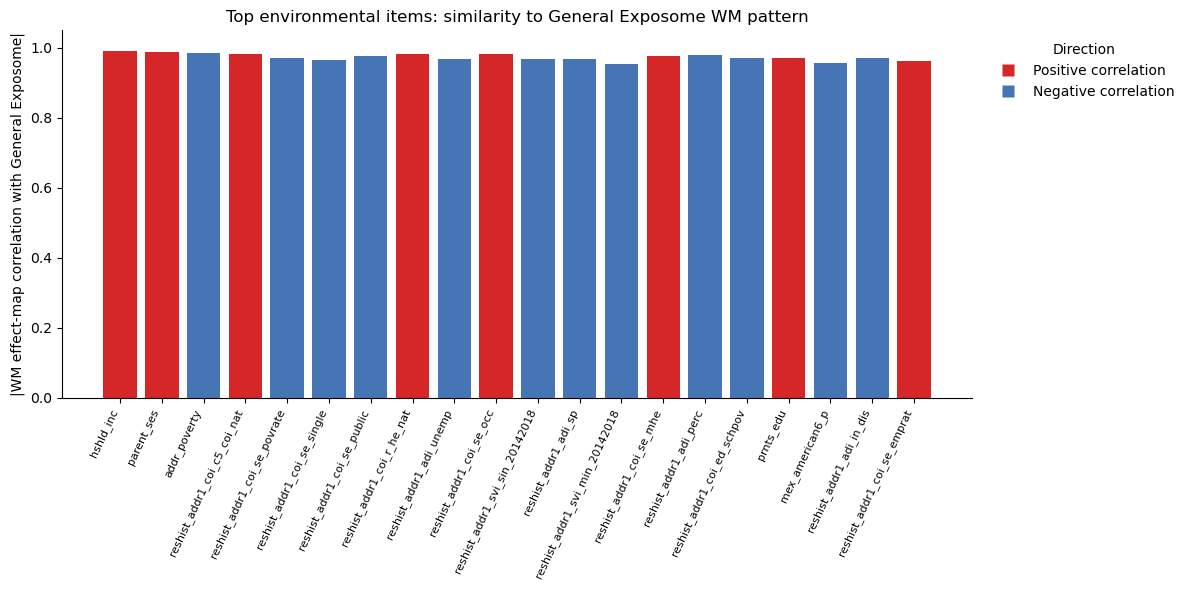

,variable,construct_category,ecological_level,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,map_r_abs,map_direction
1,hshld_inc,Socioeconomic & opportunity context,Family/household,0.075859,1057,0.991361,0.991361,Positive
0,parent_ses,Socioeconomic & opportunity context,Family/household,0.076370,1046,0.989394,0.989394,Positive
2,addr_poverty,Socioeconomic & opportunity context,Neighborhood/community,0.075079,1045,-0.984194,0.984194,Negative
3,reshist_addr1_coi_c5_coi_nat,Socioeconomic & opportunity context,Neighborhood/community,0.072278,1029,0.982516,0.982516,Positive
7,reshist_addr1_coi_se_povrate,Socioeconomic & opportunity context,Neighborhood/community,0.066697,1011,-0.971571,0.971571,Negative
4,reshist_addr1_coi_se_single,Socioeconomic & opportunity context,Neighborhood/community,0.067743,1006,-0.964849,0.964849,Negative
5,reshist_addr1_coi_se_public,Socioeconomic & opportunity context,Neighborhood/community,0.067624,1000,-0.976114,0.976114,Negative
9,reshist_addr1_coi_r_he_nat,Socioeconomic & opportunity context,Neighborhood/community,0.064951,984,0.982420,0.982420,Positive
15,reshist_addr1_adi_unemp,Socioeconomic & opportunity context,Neighborhood/community,0.060761,971,-0.967827,0.967827,Negative
6,reshist_addr1_coi_se_occ,Socioeconomic & opportunity context,Neighborhood/community,0.067208,969,0.983407,0.983407,Positive


In [22]:
# Map correlation with General Exposome for the top items.
# Select top items here so this cell does not depend on the heatmap cell being run first.
corr_rank=summary_plot.sort_values(
    [TOP_HEATMAP_RANK_BY,"mean_abs_partial_r"],ascending=[False,False]
) if TOP_HEATMAP_RANK_BY=="n_fdr_sig" else summary_plot.sort_values(TOP_HEATMAP_RANK_BY,ascending=False)

top_corr=corr_rank.head(TOP_N_HEATMAPS).copy()
top_corr["map_r_abs"]=top_corr["map_r_vs_general_exposome"].abs()
top_corr["map_direction"]=np.where(top_corr["map_r_vs_general_exposome"]>=0,"Positive","Negative")

direction_colors={"Positive":"#d62728","Negative":"#4575b4"}
bar_colors=top_corr["map_direction"].map(direction_colors)
assert bar_colors.notna().all(),"Missing direction color for map-correlation plot."

fig,ax=plt.subplots(figsize=(max(10,.6*len(top_corr)),6))
x=np.arange(len(top_corr))
ax.bar(x,top_corr["map_r_abs"],color=bar_colors.tolist())

ax.set_ylim(0,1.05)
ax.set_ylabel("|WM effect-map correlation with General Exposome|")
ax.set_xlabel("")
ax.set_title("Top environmental items: similarity to General Exposome WM pattern")
ax.set_xticks(x)
ax.set_xticklabels(top_corr["variable"],rotation=65,ha="right",fontsize=8)

direction_handles=[
    plt.Line2D([0],[0],marker="s",linestyle="",markersize=9,
               markerfacecolor=direction_colors["Positive"],markeredgecolor="none",
               label="Positive correlation"),
    plt.Line2D([0],[0],marker="s",linestyle="",markersize=9,
               markerfacecolor=direction_colors["Negative"],markeredgecolor="none",
               label="Negative correlation")
]

ax.legend(handles=direction_handles,title="Direction",
          bbox_to_anchor=(1.01,1),loc="upper left",frameon=False)

sns.despine()
plt.tight_layout()

fig.savefig(OUT_DIR/"top_items_map_correlation_with_general_exposome.png",dpi=400,bbox_inches="tight")
fig.savefig(OUT_DIR/"top_items_map_correlation_with_general_exposome.svg",bbox_inches="tight")
plt.show()

display(top_corr[[
    "variable","construct_category","ecological_level","mean_abs_partial_r","n_fdr_sig",
    "map_r_vs_general_exposome","map_r_abs","map_direction"
]])

## 14. Quick output inventory

In [18]:
print("Main outputs:")
for p in sorted(OUT_DIR.iterdir()):
    if p.is_file():
        print(" -",p.name)
print(f"\nItem heatmaps: {len(list(HEATMAP_DIR.glob('*.png')))}")

Main outputs:
 - General_SES_mass_univariate_reference.csv
 - all_item_mass_univariate_results.csv
 - brainwide_rank_mean_abs_partial_r.png
 - brainwide_rank_mean_abs_partial_r.svg
 - brainwide_rank_mean_abs_partial_r_by_construct.png
 - brainwide_rank_mean_abs_partial_r_by_construct.svg
 - brainwide_rank_mean_abs_partial_r_by_ecological_level.png
 - brainwide_rank_mean_abs_partial_r_by_ecological_level.svg
 - brainwide_rank_n_fdr_significant.png
 - brainwide_rank_n_fdr_significant.svg
 - brainwide_rank_n_fdr_significant_by_category.png
 - brainwide_rank_n_fdr_significant_by_category.svg
 - brainwide_rank_n_fdr_significant_by_construct.png
 - brainwide_rank_n_fdr_significant_by_construct.svg
 - item_99999_replacements.csv
 - item_category_mapping.csv
 - item_mass_univariate_summary.csv
 - item_mass_univariate_summary_qc_filtered.csv
 - item_missingness_and_type.csv
 - item_missingness_and_type_after_99999_cleanup.csv
 - item_missingness_in_imaging_sample.csv
 - item_vs_general_exposome

## 15. Permutation Testing

In [19]:
test_df=summary_plot.dropna(subset=["construct_category","mean_abs_partial_r"]).copy()

def between_group_ss(y,g):
    grand=np.mean(y)
    return sum(len(y[g==cat])*(np.mean(y[g==cat])-grand)**2 for cat in np.unique(g))

y=test_df["mean_abs_partial_r"].to_numpy()
g=test_df["construct_category"].to_numpy()

rng=np.random.default_rng(42)
obs_ss=between_group_ss(y,g)
perm_ss=np.array([between_group_ss(rng.permutation(y),g) for _ in range(10000)])
p_omnibus=(np.sum(perm_ss>=obs_ss)+1)/(len(perm_ss)+1)

print(f"Permutation omnibus p={p_omnibus:.4g}")

Permutation omnibus p=9.999e-05


In [20]:
from statsmodels.stats.multitest import multipletests

def permutation_mean_diff(a,b,n_perm=10000,seed=42):
    a=np.asarray(a,dtype=float); b=np.asarray(b,dtype=float)
    rng=np.random.default_rng(seed)
    pooled=np.concatenate([a,b])
    n_a=len(a)
    obs=a.mean()-b.mean()
    null=np.empty(n_perm)
    for i in range(n_perm):
        p=rng.permutation(pooled)
        null[i]=p[:n_a].mean()-p[n_a:].mean()
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(n_perm+1)
    return obs,p

ses="Socioeconomic & opportunity context"
ses_vals=test_df.loc[test_df["construct_category"]==ses,"mean_abs_partial_r"].to_numpy()

rows=[]
for cat in sorted(test_df["construct_category"].unique()):
    if cat==ses:
        continue
    other=test_df.loc[test_df["construct_category"]==cat,"mean_abs_partial_r"].to_numpy()
    diff,p=permutation_mean_diff(ses_vals,other)
    rows.append({
        "comparison":f"{ses} vs {cat}",
        "n_ses":len(ses_vals),
        "n_other":len(other),
        "mean_ses":ses_vals.mean(),
        "mean_other":other.mean(),
        "difference":diff,
        "p_perm":p
    })

ses_tests=pd.DataFrame(rows)
ses_tests["p_fdr"]=multipletests(ses_tests["p_perm"],method="fdr_bh")[1]
ses_tests=ses_tests.sort_values("difference",ascending=False)

display(ses_tests)

,comparison,n_ses,n_other,mean_ses,mean_other,difference,p_perm,p_fdr
8,Socioeconomic & opportunity context vs School ...,59,16,0.044245,0.014471,0.029774,0.000100,0.000220
3,Socioeconomic & opportunity context vs Health ...,59,8,0.044245,0.016044,0.028202,0.000200,0.000367
6,Socioeconomic & opportunity context vs Physica...,59,30,0.044245,0.016460,0.027786,0.000100,0.000220
10,Socioeconomic & opportunity context vs Substan...,59,13,0.044245,0.019527,0.024718,0.000100,0.000220
5,Socioeconomic & opportunity context vs Parenting,59,10,0.044245,0.022271,0.021974,0.000300,0.000471
0,Socioeconomic & opportunity context vs Activit...,59,35,0.044245,0.022508,0.021737,0.000100,0.000220
2,Socioeconomic & opportunity context vs Family ...,59,25,0.044245,0.023257,0.020989,0.000100,0.000220
4,Socioeconomic & opportunity context vs Neighbo...,59,14,0.044245,0.028859,0.015386,0.004100,0.005011
9,Socioeconomic & opportunity context vs Screen ...,59,15,0.044245,0.030943,0.013302,0.010099,0.011109
7,Socioeconomic & opportunity context vs Policy ...,59,5,0.044245,0.031206,0.013040,0.142486,0.142486


In [21]:
# Final downstream QC checks.
print(f"Retained environmental items: {len(summary_plot)}")
print(f"Excluded as Needs clarification: {len(summary)-len(summary_plot)}")
assert summary_plot["construct_category"].notna().all()
assert summary_plot["ecological_level"].notna().all()
assert summary_plot["variable"].is_unique
assert set(summary_plot["construct_category"]).issubset(set(construct_palette))
assert set(summary_plot["ecological_level"]).issubset(set(ecological_palette))
print("\nFinal construct counts:")
display(summary_plot["construct_category"].value_counts().reindex(construct_order).rename("n").to_frame())


Retained environmental items: 266
Excluded as Needs clarification: 0

Final construct counts:


,n
construct_category,
Socioeconomic & opportunity context,59
Family environment,25
Parenting,10
Culture & values,36
School environment,16
Neighborhood & built environment,14
Physical environment,30
Policy & structural context,5
Activities & enrichment,35
